After filtering: (600, 29)
tags: {'global': 200, 'fix_mask': 200, 'fix_nonmask': 200}
total: [np.int64(3072)]
k: [np.int64(1024)]
eps: [np.float64(0.0039)]
Saved: pdfs/object_bg_with_original_next_to_each_bin_paper_FULLK_generic.pdf


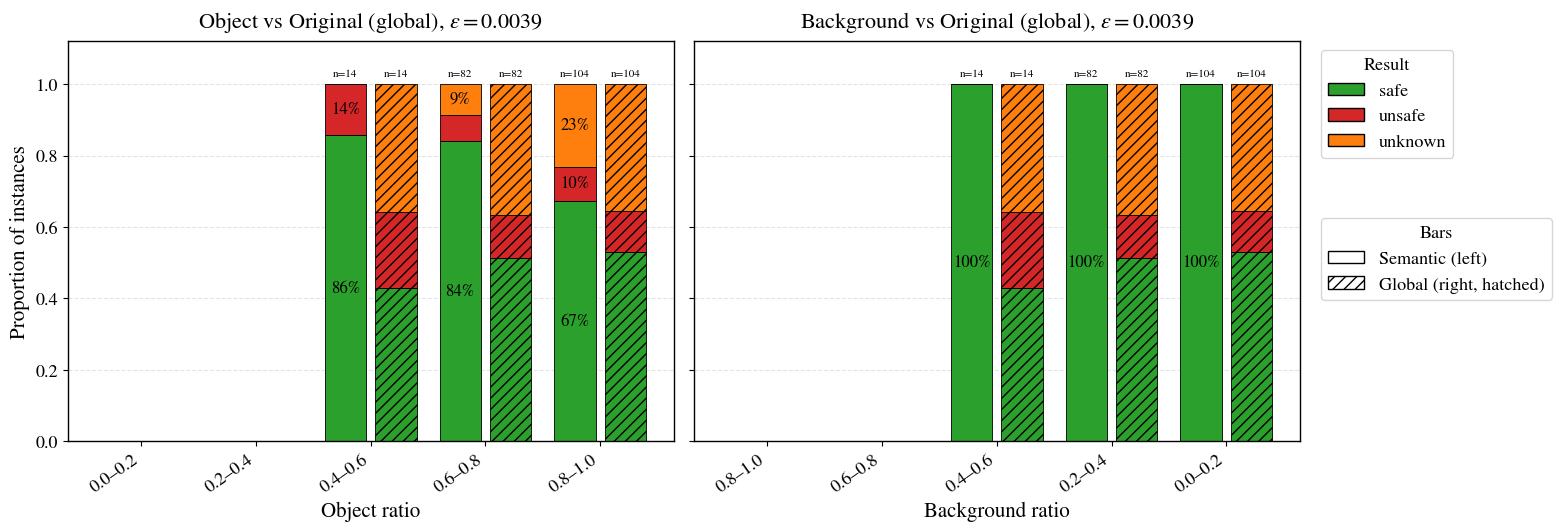

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------------------------
# Paper-ready style (fonts, sizes, lines)
# ---------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 13,

    "axes.linewidth": 1.0,
    "grid.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------
# Load
# ---------------------------
CSV_PATH = "../results/cifar100_segmented/combined_results.csv"   # <-- change if needed
df = pd.read_csv(CSV_PATH)

# ---------------------------
# Force numeric (robust to blanks)
# ---------------------------
num_cols = [
    "eps", "k", "total", "segment_index", "num_changed",
    "timeout", "domains_visited", "bab_time", "all_time",
    "percent_changed", "score"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# normalize tag/model/image to avoid whitespace issues
for c in ["tag", "model", "image"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# OPTIONAL: restrict to one model if your CSV mixes them
# df = df[df["model"] == "CIFAR100_resnet_large"].copy()

# ---------------------------
# Keep only semantic trio + full-image pixel coverage
# Full-image pixels means k == total/3 (since total counts RGB elements)
# For CIFAR100 rows: total=3072, total/3=1024
# ---------------------------
keep_tags = ["fix_mask", "fix_nonmask", "global"]
df = df[df["tag"].isin(keep_tags)].copy()

df = df.dropna(subset=["total", "k"]).copy()
df["full_k"] = (df["total"] // 3).astype(int)
df = df[df["k"].astype(int) == df["full_k"]].copy()

print("After filtering:", df.shape)
print("tags:", df["tag"].value_counts().to_dict())
print("total:", sorted(df["total"].dropna().unique()))
print("k:", sorted(df["k"].dropna().unique()))
print("eps:", sorted(df["eps"].dropna().unique()))

# ---------------------------
# Collapse results
# ---------------------------
def canon_result(x):
    s = str(x).lower()
    if "unsat" in s: return "safe"
    if "sat" in s:   return "unsafe"
    return "unknown"

df["result_cat"] = df["result"].apply(canon_result)

# ---------------------------
# Keys for pairing semantic
# Include model to prevent cross-model joins
# ---------------------------
KEY_OB = ["model", "image", "segment_index", "eps", "k", "total"]   # Object/Background pair
KEY_G  = ["model", "image", "eps", "k", "total"]                   # Global attaches without seg index

# ---------------------------
# Ratio bins
# ---------------------------
edges = np.linspace(0, 1.0, 6)   # 6 edges -> 5 bins
bin_labels = [f"{edges[i]:.1f}–{edges[i+1]:.1f}" for i in range(len(edges) - 1)]
bin_labels_rev = list(reversed(bin_labels))

COLOR = {"safe": "#2ca02c", "unknown": "#ff7f0e", "unsafe": "#d62728"}
ORDER = ["safe", "unsafe", "unknown"]  # stack order

def stacked_props(series_bins, series_result):
    counts = (
        pd.crosstab(series_bins, series_result)
        .reindex(bin_labels)
        .fillna(0)
    )
    n = counts.sum(axis=1).astype(int)
    props = counts.div(n.replace(0, np.nan), axis=0).fillna(0)
    return props, n

def paired_for_eps(eps_val):
    d = df[df["eps"] == eps_val].copy()

    obj = d[d["tag"] == "fix_nonmask"][KEY_OB + ["num_changed", "result_cat"]].copy()
    bg  = d[d["tag"] == "fix_mask"][KEY_OB + ["num_changed", "result_cat"]].copy()
    g   = d[d["tag"] == "global"][KEY_G + ["result_cat"]].copy()

    obj = obj.rename(columns={"num_changed": "obj_changed", "result_cat": "obj_result"})
    bg  = bg.rename(columns={"num_changed": "bg_changed",  "result_cat": "bg_result"})
    g   = g.rename(columns={"result_cat": "g_result"})

    # pair object + background
    paired = obj.merge(bg, on=KEY_OB, how="inner")

    # attach global (dedupe if multiple global rows per key)
    g = g.drop_duplicates(subset=KEY_G, keep="first")
    paired = paired.merge(g, on=KEY_G, how="left")

    paired["obj_ratio"] = paired["obj_changed"] / paired["total"]
    paired["bg_ratio"]  = paired["bg_changed"]  / paired["total"]

    paired["obj_bin"] = pd.cut(paired["obj_ratio"], bins=edges, labels=bin_labels, include_lowest=True)
    paired["bg_bin"]  = pd.cut(paired["bg_ratio"],  bins=edges, labels=bin_labels, include_lowest=True)

    obj_props, obj_n = stacked_props(paired["obj_bin"], paired["obj_result"])
    objG_props, _    = stacked_props(paired["obj_bin"], paired["g_result"])

    bg_props,  bg_n  = stacked_props(paired["bg_bin"],  paired["bg_result"])
    bgG_props, _     = stacked_props(paired["bg_bin"],  paired["g_result"])

    return obj_props, objG_props, obj_n, bg_props, bgG_props, bg_n, len(paired), paired["g_result"].isna().sum()

def draw_grouped_stacked(
    ax, props_A, props_B, n_per_bin, xlabels, title, xlabel,
    label_A="Semantic", label_B="Original (global)",
    width=0.36, gap=0.08,
    hatch_B="///"
):
    x = np.arange(len(xlabels))
    xA = x - (width / 2 + gap / 2)
    xB = x + (width / 2 + gap / 2)

    bottomA = np.zeros(len(xlabels))
    bottomB = np.zeros(len(xlabels))

    for lab in ORDER:
        valsA = props_A.get(lab, pd.Series(0, index=xlabels)).reindex(xlabels).fillna(0).values
        valsB = props_B.get(lab, pd.Series(0, index=xlabels)).reindex(xlabels).fillna(0).values

        # Left (semantic): solid
        ax.bar(
            xA, valsA, bottom=bottomA, width=width,
            color=COLOR[lab], edgecolor="black", linewidth=0.6
        )
        # Right (global): hatched
        ax.bar(
            xB, valsB, bottom=bottomB, width=width,
            color=COLOR[lab], edgecolor="black", linewidth=0.6, hatch=hatch_B
        )

        # Percent labels on A only
        for j, v in enumerate(valsA):
            if v >= 0.08:
                ax.text(xA[j], bottomA[j] + v / 2, f"{v*100:.0f}%",
                        ha="center", va="center", fontsize=12)

        bottomA += valsA
        bottomB += valsB

    # n labels
    n_vals = n_per_bin.reindex(xlabels).fillna(0).astype(int).values
    for j, n in enumerate(n_vals):
        if n > 0:
            ax.text(xA[j], 1.015, f"n={n}", ha="center", va="bottom", fontsize=8)
            ax.text(xB[j], 1.015, f"n={n}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=35, ha="right")
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, 1.12)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

# ---------------------------
# Plot
# ---------------------------
eps_values = sorted(df["eps"].dropna().unique())
if len(eps_values) == 0:
    raise ValueError("No eps values found after filtering.")

nrows = len(eps_values)

fig, axes = plt.subplots(
    nrows, 2,
    figsize=(15.5, 5.2 * nrows),
    sharey=True,
    constrained_layout=True
)

if nrows == 1:
    axes = np.array([axes])

for r, eps_val in enumerate(eps_values):
    obj_props, objG_props, obj_n, bg_props, bgG_props, bg_n, n_pairs, n_missing_g = paired_for_eps(eps_val)

    if n_missing_g > 0:
        print(f"Warning: eps={eps_val} has {n_missing_g} paired rows missing a matching global result.")

    draw_grouped_stacked(
        axes[r, 0],
        props_A=obj_props,
        props_B=objG_props,
        n_per_bin=obj_n,
        xlabels=bin_labels,
        title=rf"Object vs Original (global), $\epsilon={eps_val}$",
        xlabel="Object ratio",
        label_A="Object (fix_nonmask)",
        label_B="Original (global)",
        hatch_B="///"
    )

    # Background panel (reverse bins)
    bg_props_rev  = bg_props.reindex(bin_labels_rev)
    bgG_props_rev = bgG_props.reindex(bin_labels_rev)
    bg_n_rev      = bg_n.reindex(bin_labels_rev)

    draw_grouped_stacked(
        axes[r, 1],
        props_A=bg_props_rev,
        props_B=bgG_props_rev,
        n_per_bin=bg_n_rev,
        xlabels=bin_labels_rev,
        title=rf"Background vs Original (global), $\epsilon={eps_val}$",
        xlabel="Background ratio",
        label_A="Background (fix_mask)",
        label_B="Original (global)",
        hatch_B="///"
    )

for r in range(nrows):
    axes[r, 0].set_ylabel("Proportion of instances")

# Shared legend: result colors + hatch note
handles = [mpl.patches.Patch(facecolor=COLOR[k], edgecolor="black", label=k) for k in ORDER]
method_handles = [
    mpl.patches.Patch(facecolor="white", edgecolor="black", label="Semantic (left)", hatch=""),
    mpl.patches.Patch(facecolor="white", edgecolor="black", label="Global (right, hatched)", hatch="///"),
]
leg1 = axes[0, 1].legend(handles=handles, title="Result", loc="upper left", bbox_to_anchor=(1.02, 1.00))
axes[0, 1].add_artist(leg1)
axes[0, 1].legend(handles=method_handles, title="Bars", loc="upper left", bbox_to_anchor=(1.02, 0.58))

out_pdf = "pdfs/object_bg_with_original_next_to_each_bin_paper_FULLK_generic.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
print("Saved:", out_pdf)

plt.show()

After filtering: (600, 29)
tags: {'global': 200, 'fix_mask': 200, 'fix_nonmask': 200}
total: [np.int64(3072)]
k: [np.int64(1024)]
eps: [np.float64(0.0039)]
Saved: pdfs/object_bg_with_original_next_to_each_bin_paper_FULLK_generic.pdf


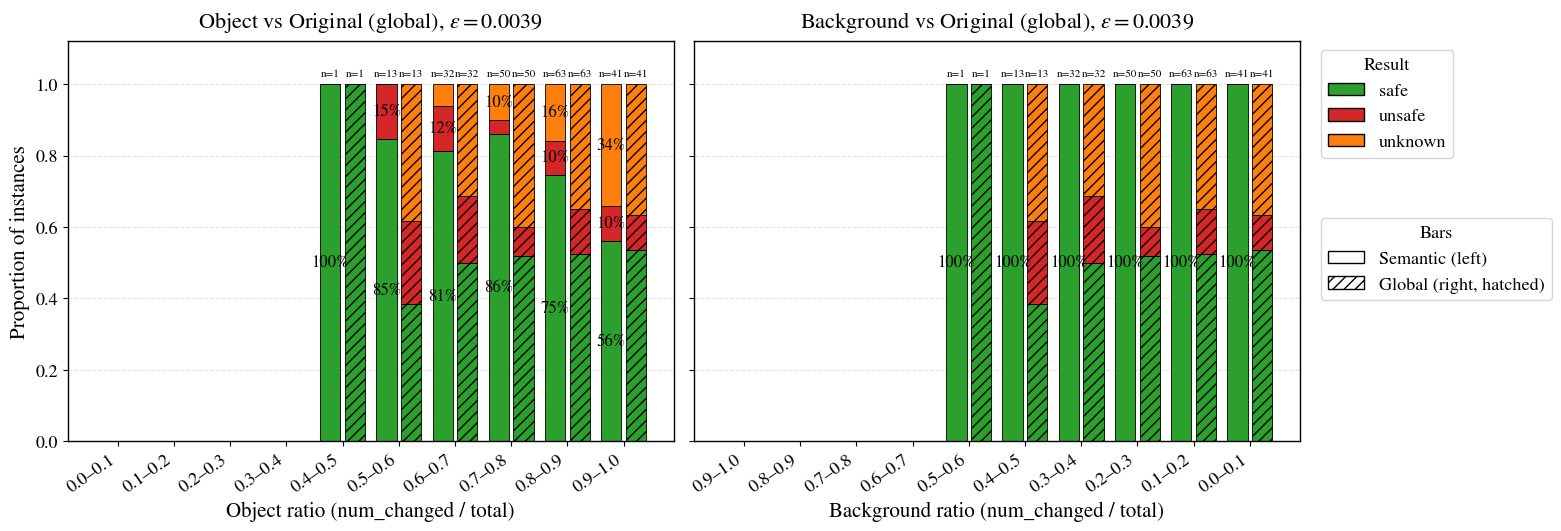

In [3]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------------------------
# Paper-ready style (fonts, sizes, lines)
# ---------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 13,

    "axes.linewidth": 1.0,
    "grid.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------
# Load
# ---------------------------
CSV_PATH = "../results/cifar100_segmented/combined_results.csv"   # <-- change if needed
df = pd.read_csv(CSV_PATH)

# ---------------------------
# Force numeric (robust to blanks)
# ---------------------------
num_cols = [
    "eps", "k", "total", "segment_index", "num_changed",
    "timeout", "domains_visited", "bab_time", "all_time",
    "percent_changed", "score"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# normalize tag/model/image to avoid whitespace issues
for c in ["tag", "model", "image"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# OPTIONAL: restrict to one model if your CSV mixes them
# df = df[df["model"] == "CIFAR100_resnet_large"].copy()

# ---------------------------
# Keep only semantic trio + full-image pixel coverage
# Full-image pixels means k == total/3 (since total counts RGB elements)
# For CIFAR100 rows: total=3072, total/3=1024
# ---------------------------
keep_tags = ["fix_mask", "fix_nonmask", "global"]
df = df[df["tag"].isin(keep_tags)].copy()

df = df.dropna(subset=["total", "k"]).copy()
df["full_k"] = (df["total"] // 3).astype(int)
df = df[df["k"].astype(int) == df["full_k"]].copy()

print("After filtering:", df.shape)
print("tags:", df["tag"].value_counts().to_dict())
print("total:", sorted(df["total"].dropna().unique()))
print("k:", sorted(df["k"].dropna().unique()))
print("eps:", sorted(df["eps"].dropna().unique()))

# ---------------------------
# Collapse results
# ---------------------------
def canon_result(x):
    s = str(x).lower()
    if "unsat" in s: return "safe"
    if "sat" in s:   return "unsafe"
    return "unknown"

df["result_cat"] = df["result"].apply(canon_result)

# ---------------------------
# Keys for pairing semantic
# Include model to prevent cross-model joins
# ---------------------------
KEY_OB = ["model", "image", "segment_index", "eps", "k", "total"]   # Object/Background pair
KEY_G  = ["model", "image", "eps", "k", "total"]                   # Global attaches without seg index

# ---------------------------
# Ratio bins
# ---------------------------
edges = np.linspace(0, 1.0, 11)
bin_labels = [f"{edges[i]:.1f}–{edges[i+1]:.1f}" for i in range(len(edges) - 1)]
bin_labels_rev = list(reversed(bin_labels))

COLOR = {"safe": "#2ca02c", "unknown": "#ff7f0e", "unsafe": "#d62728"}
ORDER = ["safe", "unsafe", "unknown"]  # stack order

def stacked_props(series_bins, series_result):
    counts = (
        pd.crosstab(series_bins, series_result)
        .reindex(bin_labels)
        .fillna(0)
    )
    n = counts.sum(axis=1).astype(int)
    props = counts.div(n.replace(0, np.nan), axis=0).fillna(0)
    return props, n

def paired_for_eps(eps_val):
    d = df[df["eps"] == eps_val].copy()

    obj = d[d["tag"] == "fix_nonmask"][KEY_OB + ["num_changed", "result_cat"]].copy()
    bg  = d[d["tag"] == "fix_mask"][KEY_OB + ["num_changed", "result_cat"]].copy()
    g   = d[d["tag"] == "global"][KEY_G + ["result_cat"]].copy()

    obj = obj.rename(columns={"num_changed": "obj_changed", "result_cat": "obj_result"})
    bg  = bg.rename(columns={"num_changed": "bg_changed",  "result_cat": "bg_result"})
    g   = g.rename(columns={"result_cat": "g_result"})

    # pair object + background
    paired = obj.merge(bg, on=KEY_OB, how="inner")

    # attach global (dedupe if multiple global rows per key)
    g = g.drop_duplicates(subset=KEY_G, keep="first")
    paired = paired.merge(g, on=KEY_G, how="left")

    paired["obj_ratio"] = paired["obj_changed"] / paired["total"]
    paired["bg_ratio"]  = paired["bg_changed"]  / paired["total"]

    paired["obj_bin"] = pd.cut(paired["obj_ratio"], bins=edges, labels=bin_labels, include_lowest=True)
    paired["bg_bin"]  = pd.cut(paired["bg_ratio"],  bins=edges, labels=bin_labels, include_lowest=True)

    obj_props, obj_n = stacked_props(paired["obj_bin"], paired["obj_result"])
    objG_props, _    = stacked_props(paired["obj_bin"], paired["g_result"])

    bg_props,  bg_n  = stacked_props(paired["bg_bin"],  paired["bg_result"])
    bgG_props, _     = stacked_props(paired["bg_bin"],  paired["g_result"])

    return obj_props, objG_props, obj_n, bg_props, bgG_props, bg_n, len(paired), paired["g_result"].isna().sum()

def draw_grouped_stacked(
    ax, props_A, props_B, n_per_bin, xlabels, title, xlabel,
    label_A="Semantic", label_B="Original (global)",
    width=0.36, gap=0.08,
    hatch_B="///"
):
    x = np.arange(len(xlabels))
    xA = x - (width / 2 + gap / 2)
    xB = x + (width / 2 + gap / 2)

    bottomA = np.zeros(len(xlabels))
    bottomB = np.zeros(len(xlabels))

    for lab in ORDER:
        valsA = props_A.get(lab, pd.Series(0, index=xlabels)).reindex(xlabels).fillna(0).values
        valsB = props_B.get(lab, pd.Series(0, index=xlabels)).reindex(xlabels).fillna(0).values

        # Left (semantic): solid
        ax.bar(
            xA, valsA, bottom=bottomA, width=width,
            color=COLOR[lab], edgecolor="black", linewidth=0.6
        )
        # Right (global): hatched
        ax.bar(
            xB, valsB, bottom=bottomB, width=width,
            color=COLOR[lab], edgecolor="black", linewidth=0.6, hatch=hatch_B
        )

        # Percent labels on A only
        for j, v in enumerate(valsA):
            if v >= 0.08:
                ax.text(xA[j], bottomA[j] + v / 2, f"{v*100:.0f}%",
                        ha="center", va="center", fontsize=12)

        bottomA += valsA
        bottomB += valsB

    # n labels
    n_vals = n_per_bin.reindex(xlabels).fillna(0).astype(int).values
    for j, n in enumerate(n_vals):
        if n > 0:
            ax.text(xA[j], 1.015, f"n={n}", ha="center", va="bottom", fontsize=8)
            ax.text(xB[j], 1.015, f"n={n}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=35, ha="right")
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, 1.12)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

# ---------------------------
# Plot
# ---------------------------
eps_values = sorted(df["eps"].dropna().unique())
if len(eps_values) == 0:
    raise ValueError("No eps values found after filtering.")

nrows = len(eps_values)

fig, axes = plt.subplots(
    nrows, 2,
    figsize=(15.5, 5.2 * nrows),
    sharey=True,
    constrained_layout=True
)

if nrows == 1:
    axes = np.array([axes])

for r, eps_val in enumerate(eps_values):
    obj_props, objG_props, obj_n, bg_props, bgG_props, bg_n, n_pairs, n_missing_g = paired_for_eps(eps_val)

    if n_missing_g > 0:
        print(f"Warning: eps={eps_val} has {n_missing_g} paired rows missing a matching global result.")

    draw_grouped_stacked(
        axes[r, 0],
        props_A=obj_props,
        props_B=objG_props,
        n_per_bin=obj_n,
        xlabels=bin_labels,
        title=rf"Object vs Original (global), $\epsilon={eps_val}$",
        xlabel="Object ratio (num_changed / total)",
        label_A="Object (fix_nonmask)",
        label_B="Original (global)",
        hatch_B="///"
    )

    # Background panel (reverse bins)
    bg_props_rev  = bg_props.reindex(bin_labels_rev)
    bgG_props_rev = bgG_props.reindex(bin_labels_rev)
    bg_n_rev      = bg_n.reindex(bin_labels_rev)

    draw_grouped_stacked(
        axes[r, 1],
        props_A=bg_props_rev,
        props_B=bgG_props_rev,
        n_per_bin=bg_n_rev,
        xlabels=bin_labels_rev,
        title=rf"Background vs Original (global), $\epsilon={eps_val}$",
        xlabel="Background ratio (num_changed / total)",
        label_A="Background (fix_mask)",
        label_B="Original (global)",
        hatch_B="///"
    )

for r in range(nrows):
    axes[r, 0].set_ylabel("Proportion of instances")

# Shared legend: result colors + hatch note
handles = [mpl.patches.Patch(facecolor=COLOR[k], edgecolor="black", label=k) for k in ORDER]
method_handles = [
    mpl.patches.Patch(facecolor="white", edgecolor="black", label="Semantic (left)", hatch=""),
    mpl.patches.Patch(facecolor="white", edgecolor="black", label="Global (right, hatched)", hatch="///"),
]
leg1 = axes[0, 1].legend(handles=handles, title="Result", loc="upper left", bbox_to_anchor=(1.02, 1.00))
axes[0, 1].add_artist(leg1)
axes[0, 1].legend(handles=method_handles, title="Bars", loc="upper left", bbox_to_anchor=(1.02, 0.58))

out_pdf = "pdfs/object_bg_with_original_next_to_each_bin_paper_FULLK_generic.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
print("Saved:", out_pdf)

plt.show()

Saved: pdfs/object_vs_background_5bins_eps0.0039.pdf


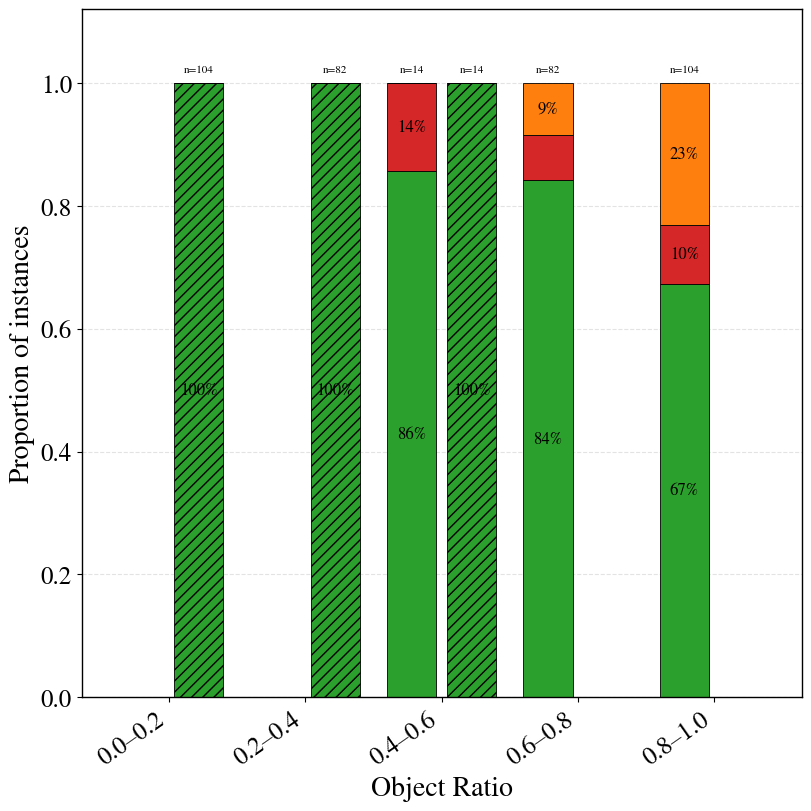

In [14]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------------------------
# Paper-ready style
# ---------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.linewidth": 1.0,
    "grid.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------
# Load
# ---------------------------
CSV_PATH = "../results/cifar100_segmented/combined_results.csv"   # <-- change if needed
df = pd.read_csv(CSV_PATH)

# ---------------------------
# Force numeric
# ---------------------------
num_cols = ["eps","k","total","segment_index","num_changed","timeout","domains_visited","bab_time","all_time","percent_changed","score"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["tag", "model", "image"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# OPTIONAL:
# df = df[df["model"] == "CIFAR100_resnet_large"].copy()

# ---------------------------
# Keep only object/background + full-image pixel coverage
# ---------------------------
keep_tags = ["fix_mask", "fix_nonmask"]
df = df[df["tag"].isin(keep_tags)].copy()

df = df.dropna(subset=["total", "k"]).copy()
df["full_k"] = (df["total"] // 3).astype(int)
df = df[df["k"].astype(int) == df["full_k"]].copy()

# ---------------------------
# Collapse results
# ---------------------------
def canon_result(x):
    s = str(x).lower()
    if "unsat" in s: return "safe"
    if "sat" in s:   return "unsafe"
    return "unknown"

df["result_cat"] = df["result"].apply(canon_result)

# ---------------------------
# Pair keys
# ---------------------------
KEY_OB = ["model", "image", "segment_index", "eps", "k", "total"]

# ---------------------------
# 5 bins
# ---------------------------
N_BINS = 5
edges = np.linspace(0, 1.0, N_BINS + 1)
bin_labels = [f"{edges[i]:.1f}–{edges[i+1]:.1f}" for i in range(N_BINS)]

COLOR = {"safe": "#2ca02c", "unknown": "#ff7f0e", "unsafe": "#d62728"}
ORDER = ["safe", "unsafe", "unknown"]

def stacked_props(series_bins, series_result):
    counts = (
        pd.crosstab(series_bins, series_result)
        .reindex(bin_labels)
        .fillna(0)
    )
    n = counts.sum(axis=1).astype(int)
    props = counts.div(n.replace(0, np.nan), axis=0).fillna(0)
    return props, n

def paired_for_eps(eps_val):
    d = df[df["eps"] == eps_val].copy()

    obj = d[d["tag"] == "fix_nonmask"][KEY_OB + ["num_changed", "result_cat"]].copy()
    bg  = d[d["tag"] == "fix_mask"][KEY_OB + ["num_changed", "result_cat"]].copy()

    obj = obj.rename(columns={"num_changed": "obj_changed", "result_cat": "obj_result"})
    bg  = bg.rename(columns={"num_changed": "bg_changed",  "result_cat": "bg_result"})

    paired = obj.merge(bg, on=KEY_OB, how="inner")

    paired["obj_ratio"] = paired["obj_changed"] / paired["total"]
    paired["bg_ratio"]  = paired["bg_changed"]  / paired["total"]

    paired["obj_bin"] = pd.cut(paired["obj_ratio"], bins=edges, labels=bin_labels, include_lowest=True)
    paired["bg_bin"]  = pd.cut(paired["bg_ratio"],  bins=edges, labels=bin_labels, include_lowest=True)

    obj_props, obj_n = stacked_props(paired["obj_bin"], paired["obj_result"])
    bg_props,  bg_n  = stacked_props(paired["bg_bin"],  paired["bg_result"])

    return obj_props, obj_n, bg_props, bg_n

def draw_grouped_stacked_OB(
    ax, props_obj, props_bg, n_obj, n_bg, xlabels,
    title, xlabel,
    width=0.36, gap=0.08,
    hatch_bg="///",
    show_n=True,
    show_pct=True,
    pct_thresh=0.08
):
    x = np.arange(len(xlabels))
    xO = x - (width / 2 + gap / 2)
    xB = x + (width / 2 + gap / 2)

    bottomO = np.zeros(len(xlabels))
    bottomB = np.zeros(len(xlabels))

    for lab in ORDER:
        valsO = props_obj.get(lab, pd.Series(0, index=xlabels)).reindex(xlabels).fillna(0).values
        valsB = props_bg.get(lab,  pd.Series(0, index=xlabels)).reindex(xlabels).fillna(0).values

        ax.bar(xO, valsO, bottom=bottomO, width=width,
               color=COLOR[lab], edgecolor="black", linewidth=0.6)
        ax.bar(xB, valsB, bottom=bottomB, width=width,
               color=COLOR[lab], edgecolor="black", linewidth=0.6, hatch=hatch_bg)

        if show_pct:
            for j, v in enumerate(valsO):
                if v >= pct_thresh:
                    ax.text(xO[j], bottomO[j] + v/2, f"{v*100:.0f}%",
                            ha="center", va="center", fontsize=12)
            for j, v in enumerate(valsB):
                if v >= pct_thresh:
                    ax.text(xB[j], bottomB[j] + v/2, f"{v*100:.0f}%",
                            ha="center", va="center", fontsize=12)

        bottomO += valsO
        bottomB += valsB

    if show_n:
        nO = n_obj.reindex(xlabels).fillna(0).astype(int).values
        nB = n_bg.reindex(xlabels).fillna(0).astype(int).values
        for j in range(len(xlabels)):
            if nO[j] > 0:
                ax.text(xO[j], 1.015, f"n={nO[j]}", ha="center", va="bottom", fontsize=8)
            if nB[j] > 0:
                ax.text(xB[j], 1.015, f"n={nB[j]}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=35, ha="right")
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Proportion of instances")
    ax.set_ylim(0, 1.12)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

# ---------------------------
# Plot: square figure PER eps
# ---------------------------
eps_values = sorted(df["eps"].dropna().unique())
if len(eps_values) == 0:
    raise ValueError("No eps values found after filtering.")

for eps_val in eps_values:
    obj_props, obj_n, bg_props, bg_n = paired_for_eps(eps_val)

    fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)

    draw_grouped_stacked_OB(
        ax,
        props_obj=obj_props,
        props_bg=bg_props,
        n_obj=obj_n,
        n_bg=bg_n,
        xlabels=bin_labels,
        title=rf"",
        xlabel="Object Ratio",
        hatch_bg="///",
        show_n=True,
        show_pct=True,
        pct_thresh=0.08
    )

    out_pdf = f"pdfs/object_vs_background_5bins_eps{eps_val}.pdf"
    fig.savefig(out_pdf, bbox_inches="tight")
    print("Saved:", out_pdf)
    plt.show()